
## Sterberaten von Europäischen Ländern im Jahr 2009
### 1 These: Im Jahr 2009 wiesen osteuropäische Länder deutlich höhere Sterberaten pro 100 000 Einwohner auf als westeuropäische Länder.

Wir haben uns dazu entschieden in diesem Teil der Arbeit nur Europa zu untersuchen, weil deren Todesstatistiken verlässlich und vollständig sind. 

In [51]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Data_Files/base_data104_with_lookup.csv", low_memory=False)


Zuerst suchen wir das Jahr X bei dem es am meisten verschiedene Länder gibt. Dieses eignet sich am besten für die weiterführende Analyse.

In [3]:
# Anzahl Länder pro Jahr
df_year_counts = df.groupby("Year")["Country"].nunique().reset_index()

df_year_counts.columns = ["Year", "NumCountries"]
df_year_counts.sort_values("NumCountries", ascending=False)


,Year,NumCountries
21,2009,97
22,2010,95
29,2017,93
24,2012,93
28,2016,93
25,2013,93
26,2014,93
30,2018,92
27,2015,91
23,2011,91


#### Prüfen auf doppelte Einträge
Die WHO-Mortalitätsdaten enthalten für viele Länder mehrere Zeilen pro Kombination aus Land, Todesursache und Jahr
Mit duplicated() prüfen wir, wie viele Zeilen im Jahr 2009 potentielle Duplikate sind


In [12]:
year = 2009
death_col = "Deaths at all ages"

df_y = df[df["Year"] == year].copy()

# Wie viele potenzielle Duplikate pro Country/Cause/Sex?
dup_count = df_y.duplicated(subset=["Country","Cause","Sex"], keep=False).sum()
dup_count


np.int64(28750)

#### Bereinigung der Duplikate
Für alle Duplikate, behalten wir jeweils den maximalen Wert. Dies ist sinnvoll weil bei der WHO manchmal unterschiedliche Versionen gemeldet werden. Die höchste Zahl ist meistens die letzte finale Version und daher macht es auch sinn diese weiter zu verwenden. df_unique enthält keine Doppelzählungen

In [13]:
death_col = "Deaths at all ages"

df_unique = (
    df_y
    .groupby(["Country", "Cause", "Sex"], as_index=False)[death_col]
    .max()   # wichtig: nimm den Höchstwert, nicht die Summe
)


Wir werden mit dem Jahr 2009 fortfahren. Zuerst summieren wir die Todesfälle pro Land im Jahr 2009

In [19]:
df_2009 = df[df["Year"] == 2009]
death_col = "Deaths at all ages"  

df_deaths = (
    df_unique.groupby("Country", as_index=False)[death_col]
           .sum()
)
df_deaths.head()

,Country,Deaths at all ages
0,Anguilla,67
1,Antigua and Barbuda,347
2,Argentina,291113
3,Aruba,590
4,Australia,134198


Wir haben ein Csv-File "population_2009.csv" erstellt. Dieses enthält die Populationsdaten aller Länder, die wir brauchen.
Quelle: https://data.worldbank.org/indicator/SP.POP.TOTL?end=2024&most_recent_year_desc=true&start=1981

Wir mergen nun die Populationsdaten mit den df_deaths. Mit hilfe dieser Daten berechnen wir Todesfälle pro 100'000 Einwohner, da dies aufgrund unterschiedlicher Bevölkerungszahlen aussagekräftiger ist. 

In [25]:
pop = pd.read_csv("Data_Files/population_2009.csv")
df_rate = df_deaths.merge(pop, on="Country", how="left")
df_rate["Deaths_per_100k"] = df_rate["Deaths at all ages"] / df_rate["Population_2009"] * 100_000

#Ausgabe zum Überprüfen
display(df_rate.sort_values("Deaths_per_100k", ascending=False).head(10))
display(df_rate.sort_values("Deaths_per_100k", ascending=True).head(10))


,Country,Deaths at all ages,Population_2009,Deaths_per_100k
49,Latvia,28184,2249116,1253.114557
39,Hungary,124432,10030975,1240.477621
50,Lithuania,38512,3324353,1158.481064
74,Romania,248781,21478450,1158.281906
18,Croatia,50145,4331891,1157.577603
27,Estonia,14954,1340127,1115.864392
71,Republic of Moldova,39650,3573472,1109.565151
31,Georgia,45812,4262140,1074.859108
32,Germany,826447,81802257,1010.298530
92,"United Kingdom, Scotland",51945,5194000,1000.096265


,Country,Deaths at all ages,Population_2009,Deaths_per_100k
37,Honduras,4912,7388727,66.479652
79,Saudi Arabia,38110,27448595,138.841351
57,Morocco,48630,31851000,152.679665
62,Occupied Palestinian Territory,6261,4048000,154.668972
86,Tunisia,19915,10468825,190.231473
47,Kuwait,5597,2735727,204.589127
46,Jordan,14030,6077103,230.866582
88,Turks and Caicos Islands,71,30000,236.666667
24,Dominican Republic,23426,9673665,242.162614
14,Cayman Islands,137,54397,251.852124


#### Filtern nach Europa
Wie bereits erklärt fokussieren wir uns hier aufgrund der Datenqulität nur auf Europa. Solche mit einer Todesrate von unter 500 fallen raus, da dies sehr unrealistisch ist und es sich bei diesen sehr wahrscheinlich um unvollständige Daten handelt.

In [33]:
europe_countries = [
    "Albania", "Andorra", "Armenia", "Austria", "Azerbaijan", "Belarus", "Belgium",
    "Bosnia and Herzegovina", "Bulgaria", "Croatia", "Cyprus", "Czech Republic",
    "Denmark", "Estonia", "Finland", "France", "Georgia", "Germany", "Greece",
    "Hungary", "Iceland", "Ireland", "Italy", "Kazakhstan",
    "Latvia", "Lithuania", "Luxembourg", "Malta", "Republic of Moldova",
    "Monaco", "Montenegro", "Netherlands", "North Macedonia", "Norway",
    "Poland", "Portugal", "Romania", "Russian Federation", "San Marino",
    "Serbia", "Slovakia", "Slovenia", "Spain", "Sweden", "Switzerland",
    "Tajikistan", "Turkey", "Turkmenistan", "Ukraine", "United Kingdom",
    "Uzbekistan", "Armenia"
]
df_europa = df_rate[df_rate["Country"].isin(europe_countries)].copy()
df_europa.sort_values("Deaths_per_100k", ascending=False).head(10)

df_europa_clean = df_europa[df_europa["Deaths_per_100k"] >= 500].copy()
display(df_europa_clean.sort_values("Deaths_per_100k", ascending=True).head(50))



,Country,Deaths at all ages,Population_2009,Deaths_per_100k
40,Iceland,1905,319014,597.152476
41,Ireland,27323,4503730,606.674912
51,Luxembourg,3352,493500,679.229990
52,Malta,3108,413609,751.434326
84,Switzerland,59273,7785805,761.295717
58,Netherlands,130040,16485787,788.800680
29,France,511379,64479107,793.092559
80,Spain,375001,45931174,816.441139
61,Norway,39699,4858199,817.154670
89,United Kingdom,544965,62041708,878.384908


#### Karte erstellen
Wir erstellen eine interaktive Karte von Europa, welche die Todesrate pro 100'000 zeigt. Je höher die Todesrate, desto röter werden die Länder gezeigt. Es wir ein html-File generiert.

In [ ]:

df = df_europa_clean.copy()
rate_col = "Deaths_per_100k"

#Wir müssen die Namen Plotly kompatibel machen
if "Country_plotly" not in df.columns:
    name_fix = {
        "Czech Republic": "Czechia",
        "Republic of Moldova": "Moldova",
        "Russian Federation": "Russia",
        "United Kingdom, England and Wales": "United Kingdom",
        "United Kingdom, Northern Ireland": "United Kingdom",
        "United Kingdom, Scotland": "United Kingdom",
        "Bosnia and Herzegovina": "Bosnia and Herz.",
    }
    df["Country_plotly"] = df["Country"].astype(str).replace(name_fix)

fig = px.choropleth(
    df,
    locations="Country_plotly",
    locationmode="country names",
    color=rate_col,
    color_continuous_scale="Reds",
    hover_name="Country",
    hover_data={
        rate_col: ":.0f",
        "Population_2009": True,
        "Deaths at all ages": True,
        "Country_plotly": False,
    },
    title="Sterberate pro 100 000 Einwohner/Europa (2009)",
)

fig.update_layout(
    margin=dict(l=0, r=0, t=60, b=0),
    coloraxis_colorbar=dict(title="pro 100k"),
    geo=dict(scope="europe", showcountries=True),
)

fig.write_html("europe_deaths_per_100k_2009.html", include_plotlyjs="cdn")


C:\Users\nevio\AppData\Local\Temp\ipykernel_28680\3145921525.py:17: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



C:\Users\nevio\AppData\Local\Temp\ipykernel_28680\1601973465.py:20: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



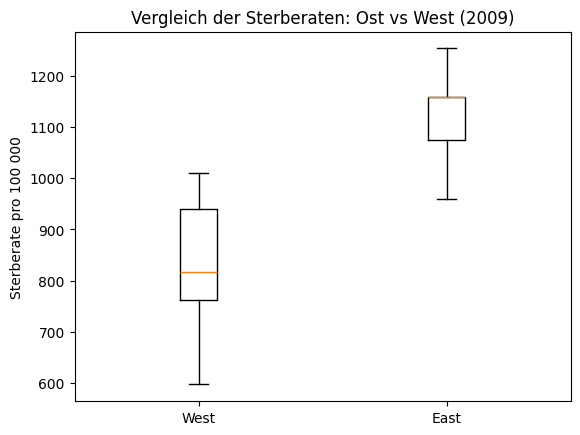

In [52]:
west_europe = [ "Iceland", "Ireland", "United Kingdom", "Portugal", "Spain", "France", "Belgium", "Netherlands", "Luxembourg", "Switzerland", "Austria", "Germany", "Denmark", "Norway", "Sweden", "Finland", "Italy", "Malta"]
east_europe = ["Poland", "Czech Republic", "Slovakia", "Hungary", "Romania", "Bulgaria", "Lithuania", "Latvia", "Estonia", "Ukraine", "Belarus", "Moldova", "Georgia", "Armenia", "Azerbaijan", "Kazakhstan", "Kyrgyzstan", "Turkey", "Cyprus", "Serbia", "Croatia", "Bosnia and Herzegovina","North Macedonia", "Montenegro", "Slovenia"]

def label_region(country):
    if country in west_europe:
        return "West"
    elif country in east_europe:
        return "East"
    return "Other"

df_europa_clean["Region"] = df_europa_clean["Country"].apply(label_region)

df_regions = df_europa_clean[df_europa_clean["Region"].isin(["East", "West"])].copy()

data_to_plot = [
    df_regions[df_regions["Region"] == "West"]["Deaths_per_100k"],
    df_regions[df_regions["Region"] == "East"]["Deaths_per_100k"]
]

plt.boxplot(data_to_plot, labels=["West", "East"])
plt.ylabel("Sterberate pro 100 000")
plt.title("Vergleich der Sterberaten: Ost vs West (2009)")

plt.show()



#### Analyse These 1
Die interaktive Karte zeigt eine klare räumliche Musterbildung der Sterberaten. Länder in Osteuropa sind deutlich dunkler gefärbt und weisen daher auch höher Sterberaten auf als westliche Länder. Die Sterberate pro 100'000 Einwohner leigt in Osteuropa meistens über 1'100. Damit liegen diese Länder klar an der Spitze.
Damgegenüber erscheinen westeuropäische Länder in helleren Farben. Diese Länder deutlich tiefere Sterberaten. 
Skandinavische Länder liegen im mittleren Bereich. 
Aufällig ist, dass die Lettland die höchste Sterberate hat, was möglicherweise mit der Wirtschaftskrise zusammenhängen könnte. 
Die Karte bestätigt somit die These. Die Sterberaten im Jahr 2009 waren im östlichen Europa deutlich höher als im westlichen Europa